

# Transfer Learning on E. coli to S. aureus

#### Mukundan Thanigaivelan, <thanigam@union.edu>

#### June 12, 2026

This notebook contains work on training Denoising Autoencoders on E. coli RNA-Seq data, and fine-tuning these models on S. aureus data to assess if transfer learning helps the model learn S. aureus pathways.

#### Outline

0. Before anything, we connect to the GitHub repository.
1. First we'll load classes from adage and modules for plotting, etc.
2. Next we'll take a look at the training data!
3. Train some models with hyperparameters from previous search.
4. Plot training loss over epochs.
5. Plot weight distributions of final models.

## 0. Connect to GitHub

In [1]:
!git clone https://github.com/Mukundan-T/seqADAGE.git

Cloning into 'seqADAGE'...
remote: Enumerating objects: 446, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (102/102), done.
remote: Total 446 (delta 63), reused 50 (delta 17), pack-reused 323 (from 1)
Receiving objects: 100% (446/446), 45.46 MiB | 15.92 MiB/s, done.
Resolving deltas: 100% (216/216), done.


In [2]:
%cd seqADAGE/Py/muk_transfer_learning

/content/seqADAGE/Py/muk_transfer_learning


In [3]:
!pip install -qq tensorflow keras statsmodels seaborn plotnine_prism pydeseq2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.6/45.6 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.1/176.1 kB 17.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.9/118.9 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 75.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.7/73.7 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.0/346.0 kB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 144.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.6/87.6 kB 9.7 MB/s eta 0:00:00


## 1. Loading classes, modules

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

In [6]:
# ADAGE
from adage import Adage as ad
from adage import SeqAdage

# Data Analysis
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from plotnine_prism import *

# Miscellaneous
import time
import tensorflow as tf
from pydeseq2.preprocessing import deseq2_norm

In [7]:
# check CPU and GPU available in runtime
print("Num CPUs Available: ", len(tf.config.list_physical_devices('CPU')))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print(tf.test.is_built_with_cuda())

Num CPUs Available:  1
Num GPUs Available:  1
True


## 2. Training Data - EDA

Here we are looking at two training datasets. The first only has genes
in MG1655 and the second has genes in either MG1655 or a couple isolates
of interest (to include eloD genes).

### MG1655 genes

This compendium only has genes in MG1655 and samples have been filtered
by sparsity and housekeeping gene expression.

The data has been log transformed and scaled to be between 0 and 1.

#### Preparation

In [8]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [9]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 4272 genes (features) and 16150 samples


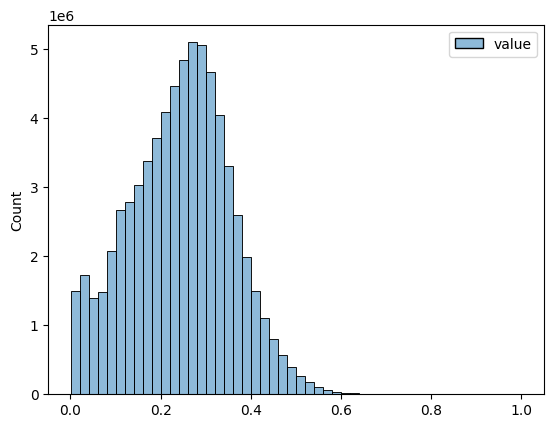

In [10]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

#### Gene-wise Filtering

In [11]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
11997cc26382b2c286cd502685a104a5_13,16150.0,0.290959,0.049891,0.005090,0.263131,0.284746,0.309190,0.571206
11997cc26382b2c286cd502685a104a5_45,16150.0,0.277920,0.057231,0.002175,0.261675,0.284082,0.305577,0.597320
11997cc26382b2c286cd502685a104a5_102,16150.0,0.213072,0.107602,0.000692,0.119966,0.243526,0.290658,0.742326
11997cc26382b2c286cd502685a104a5_110,16150.0,0.312207,0.066389,0.032919,0.295633,0.324393,0.347428,0.754336
11997cc26382b2c286cd502685a104a5_72,16150.0,0.364656,0.082157,0.022983,0.299426,0.356862,0.427053,0.715735


Text(0.5, 1.0, 'Mean vs. Median expression')

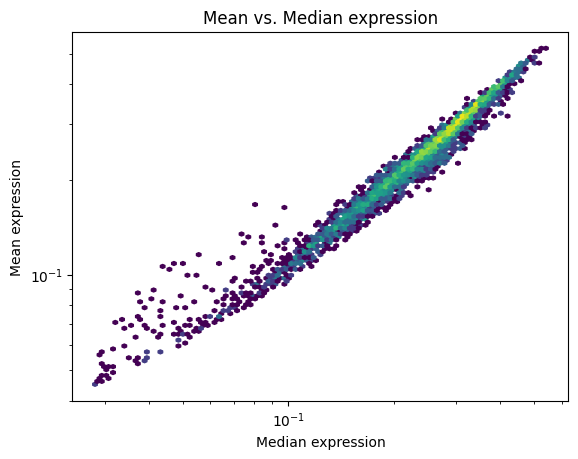

In [225]:
# Preliminary hexagonal binning log-scaled plot of median versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [226]:
# Empirically determined constants to draw a separation line
c = 0.9
median_cutoff = 0.12

x = np.linspace(median_cutoff, 0.6, 200)
y = c*x

Text(0.5, 1.0, 'Mean vs. Median expression')

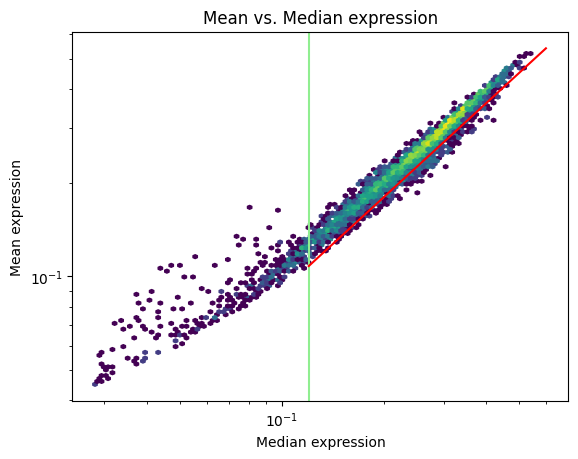

In [227]:
# Hexagonal binning log-scaled plot of median versus mean - included thresholds
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.axvline(median_cutoff, color = 'lightgreen')
plt.plot(x, y, color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [228]:
# Set thresholds to remove genes
threshold1 = median_cutoff
threshold2 = c*gene_stats['50%']

# Genes to remove
genes_to_rm = gene_stats[(gene_stats['50%'] < threshold1) | (gene_stats['mean'] < threshold2)]
genes_to_rm.shape

(664, 8)

In [230]:
# Remove the genes
filtered_genes = all_comp.drop(index = genes_to_rm.index)
filtered_genes.shape

(3608, 16150)

In [231]:
# Get filtered gene stats
filtered_stats = filtered_genes.T.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

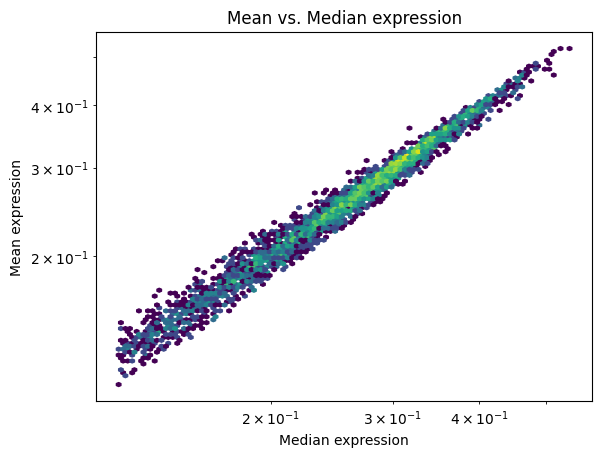

In [232]:
# Plot of gene expression median versus mean after filtering
plt.hexbin(
  x = filtered_stats['50%'],
  y = filtered_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

<Axes: ylabel='Count'>

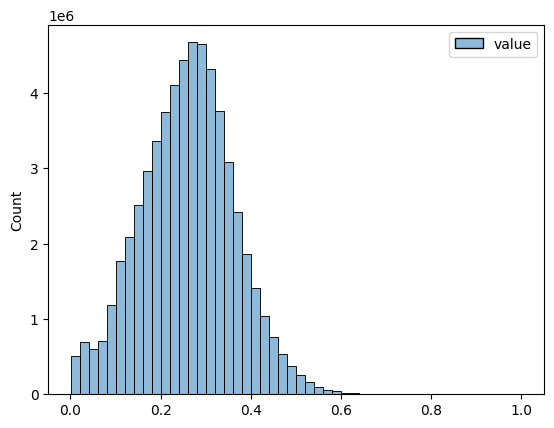

In [233]:
# Histogram of gene expression - getting normal but needs work
sns.histplot(pd.melt(filtered_genes), bins=50)

#### Experiment-wise Filtering

In [234]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358242.salmon,3608.0,0.259334,0.080874,0.037627,0.207913,0.258373,0.309569,0.538706
ERX358243.salmon,3608.0,0.260587,0.085040,0.026616,0.205225,0.260042,0.315398,0.536585
ERX358244.salmon,3608.0,0.259824,0.082692,0.025180,0.207999,0.258959,0.313029,0.527667
ERX358245.salmon,3608.0,0.260435,0.085708,0.039842,0.204903,0.261084,0.316369,0.559430
ERX358246.salmon,3608.0,0.258781,0.089028,0.027814,0.201201,0.258916,0.316990,0.549574


Text(0.5, 1.0, 'Mean vs. Median expression')

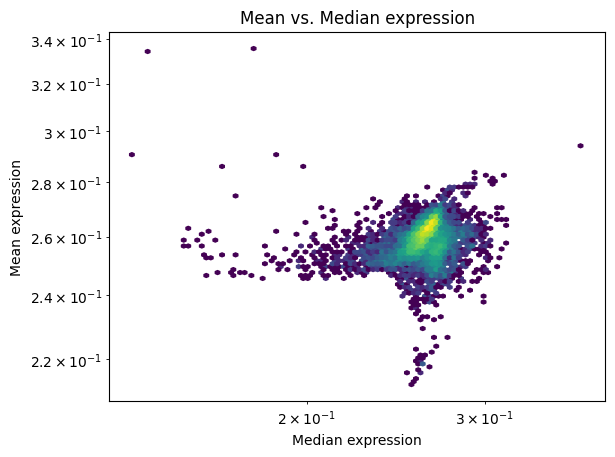

In [236]:
# Prelimiary plot of mean by median expression - weird shape
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [238]:
# Empirically derived constants to filter out samples
c1, c2 = 0.98, 1.02

# Cutoff lines to filter samples
x = np.linspace(0.21, 0.31, 200)
y1 = c1 * x
y2 = c2 * x

Text(0.5, 1.0, 'Mean vs. Median expression')

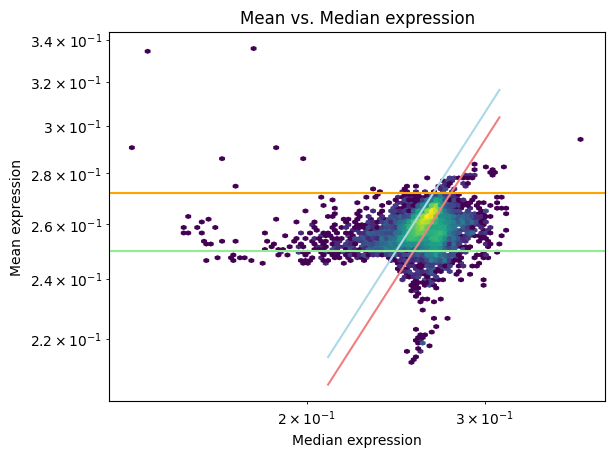

In [242]:
# Plot with threshold lines for filtering out samples
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)

plt.plot(x, y1, color = 'lightcoral')
plt.plot(x, y2, color = 'lightblue')
plt.axhline(0.25, color = 'lightgreen')
plt.axhline(0.272, color = 'orange')

plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

In [243]:
# Thresholds to filter out samples
threshold1 = c1 * exp_stats['50%']
threshold2 = c2 * exp_stats['50%']
threshold3 = 0.25
threshold4 = 0.272

# Samples to remove
exps_to_rm = exp_stats[
  (exp_stats['mean'] < threshold1) |
  (exp_stats['mean'] > threshold2) |
  (exp_stats['mean'] < threshold3) |
  (exp_stats['mean'] > threshold4)
]
exps_to_rm.shape

(5996, 8)

In [244]:
# Get final filtered data set
filtered_df = filtered_genes.drop(columns = exps_to_rm.index)
filtered_df.shape

(3608, 10154)

In [245]:
# Get statistics on final data
final_stats = filtered_df.describe().T

Text(0.5, 1.0, 'Mean vs. Median expression')

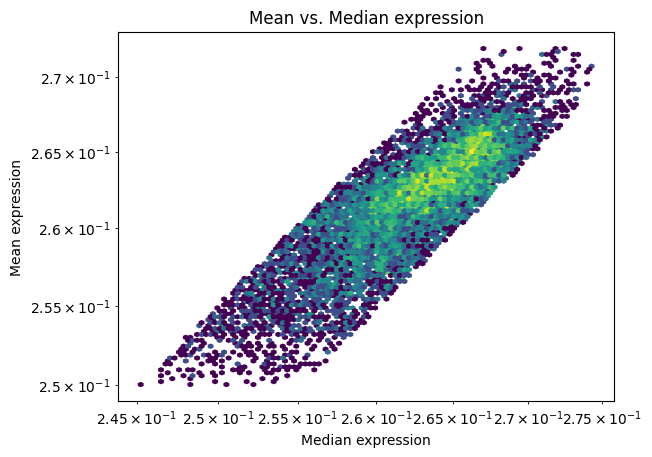

In [246]:
# Plot of filtered samples gene mean versus median
plt.hexbin(
  x = final_stats['50%'],
  y = final_stats['mean'],
  bins = 'log',
  xscale = 'log',
  yscale = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Mean expression")
plt.title("Mean vs. Median expression")

<Axes: ylabel='Count'>

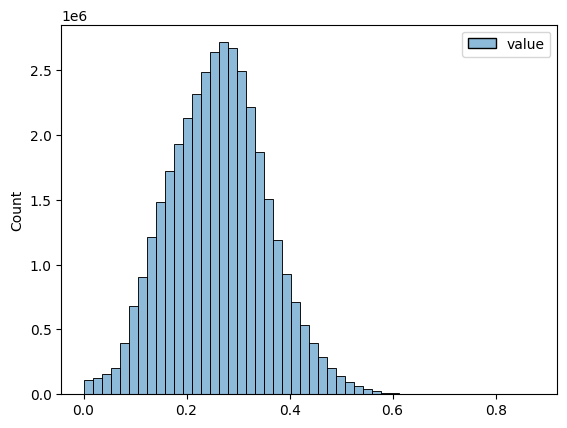

In [247]:
# Histogram of final filtered data - pretty normal!
sns.histplot(pd.melt(filtered_df.T), bins = 50)

#### Final Filtered Data

In [248]:
# Get size of filtered genes and samples
filtered_df.shape

(3608, 10154)

### MG1655+ genes

This compendium has genes in MG1655 or a couple other strains/isoaltes
and samples have been filtered by sparsity and housekeeping gene
expression, but are expected to be more sparse given the presence of
strain-specific accessory genes.

The data has been log transformed and scaled to be between 0 and 1.

#### Preparation

In [ ]:
all_comp = pd.read_csv('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmgp_lcn01.csv', index_col = 0)
gene_num = np.size(all_comp, 0)
samp_num = np.size(all_comp, 1)

In [ ]:
print(f"There are {gene_num} genes (features) and {samp_num} samples")

There are 6390 genes (features) and 16122 samples


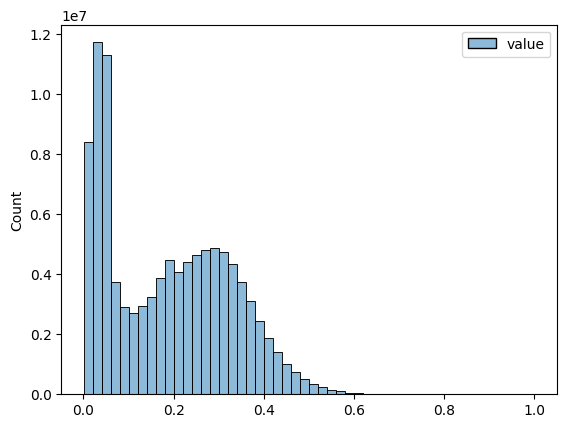

In [ ]:
fig = sns.histplot(pd.melt(all_comp), bins = 50)

#### Gene-wise Filtering

In [ ]:
# Get gene sample statistics
gene_stats = all_comp.T.describe().T
gene_stats.head()

,count,mean,std,min,25%,50%,75%,max
0ed86576d343ce011a61773e0620e335_1041,16122.0,0.077232,0.075301,0.000886,0.024035,0.042847,0.122534,0.534683
0ed86576d343ce011a61773e0620e335_1045,16122.0,0.087295,0.057721,0.003279,0.043884,0.072425,0.116301,0.487094
0ed86576d343ce011a61773e0620e335_1476,16122.0,0.163536,0.077092,0.002585,0.103627,0.179839,0.213743,0.473169
0ed86576d343ce011a61773e0620e335_1484,16122.0,0.069370,0.056209,0.000886,0.025019,0.046082,0.108003,0.470536
0ed86576d343ce011a61773e0620e335_2130,16122.0,0.088783,0.051069,0.004582,0.048053,0.079310,0.117704,0.431915


Text(0.5, 1.0, 'Variance vs. Mean expression')

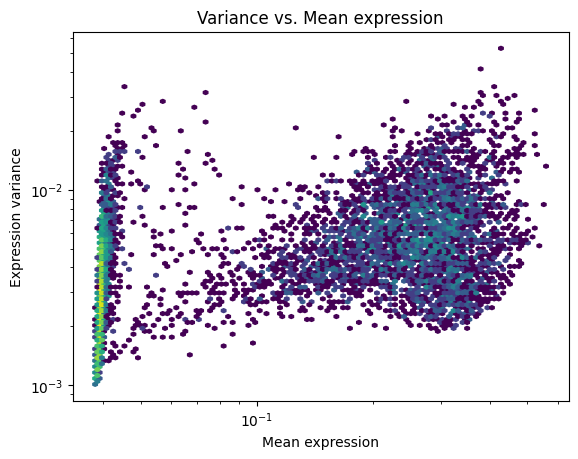

In [ ]:
# Preliminary hexagonal binning log-scaled plot of variance versus mean
plt.hexbin(
  x = gene_stats['50%'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

<Axes: xlabel='std', ylabel='Count'>

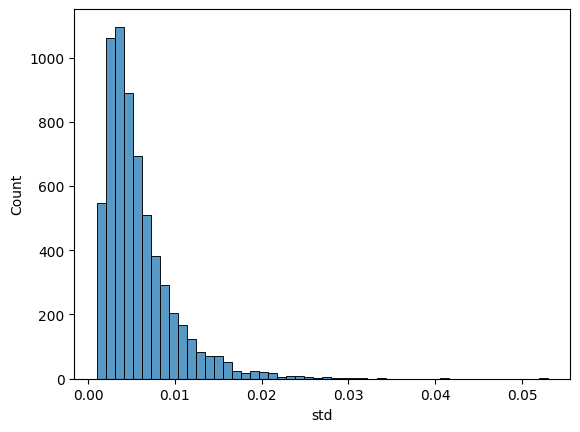

In [ ]:
# Plot variance distribution
sns.histplot(gene_stats['std'] ** 2, bins = 50)

In [ ]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(gene_stats['std'] ** 2, 25)

# Pull bottom 25% variance genes
low_var_genes = gene_stats[gene_stats['std'] ** 2 < var_cutoff]

low_var_genes.shape

(1598, 8)

<Axes: xlabel='mean', ylabel='Count'>

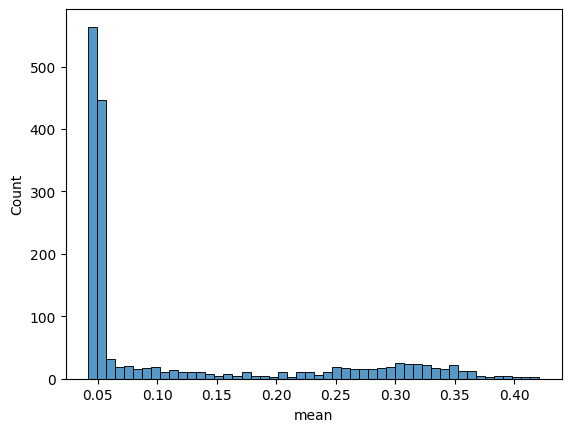

In [ ]:
low_var_genes = all_comp.T[low_var_genes.index].describe().T
sns.histplot(low_var_genes['mean'], bins = 50)

In [ ]:
# Get 40th percentile cutoff
mean_cutoff = np.percentile(low_var_genes['mean'], 40)

# Pull bottom 40% mean genes
genes_to_rm = low_var_genes[low_var_genes['mean'] < mean_cutoff]

genes_to_rm.shape

(639, 8)

Text(0.5, 1.0, 'Variance vs. Mean expression')

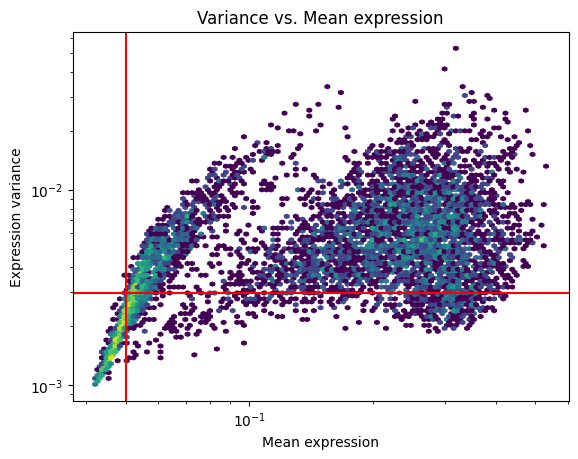

In [ ]:
# Hexagonal binning log-scaled plot of variance versus mean - lower left quadrant represents
# genes to filter out
plt.hexbin(
  x = gene_stats['mean'],
  y = gene_stats['std'] ** 2,
  bins='log',
  xscale='log',
  yscale='log'
)
plt.axvline(genes_to_rm['mean'].max(), color = 'red')
plt.axhline((genes_to_rm['std'] ** 2).max(), color = 'red')

plt.xlabel("Mean expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. Mean expression")

In [ ]:
filtered_genes = all_comp.drop(genes_to_rm.index, axis = 0)
filtered_genes.head()

,ERX358243,ERX358244,ERX358245,ERX358246,ERX358247,ERX358248,ERX358249,ERX644787,ERX644788,ERX644789,...,SRX28568279,SRX28568280,SRX28568281,SRX28568282,SRX28568283,SRX28568284,SRX28568285,SRX28568286,SRX28568287,SRX28568288
0ed86576d343ce011a61773e0620e335_1041,0.171148,0.037750,0.042322,0.039481,0.045178,0.030353,0.234787,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.020627,0.037324,0.174210,0.037212,0.184049,0.026891
0ed86576d343ce011a61773e0620e335_1045,0.132580,0.215529,0.131003,0.178620,0.085422,0.098022,0.108496,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.056321,0.074138,0.031145,0.037212,0.037601,0.026891
0ed86576d343ce011a61773e0620e335_1476,0.291676,0.313923,0.311423,0.323608,0.228029,0.310924,0.045566,0.169165,0.128144,0.127795,...,0.183638,0.198502,0.200135,0.176668,0.188772,0.197787,0.182673,0.188009,0.096002,0.190439
0ed86576d343ce011a61773e0620e335_1484,0.037630,0.037750,0.170422,0.039481,0.045178,0.030353,0.136272,0.115597,0.128144,0.127795,...,0.014785,0.010631,0.015451,0.025898,0.020627,0.110703,0.031145,0.037212,0.037601,0.026891
0ed86576d343ce011a61773e0620e335_2130,0.195812,0.234322,0.136092,0.135860,0.045178,0.118685,0.187253,0.115597,0.128144,0.127795,...,0.075937,0.068542,0.085528,0.025898,0.020627,0.074138,0.031145,0.037212,0.074549,0.044574


#### Experiment-wise Filtering

In [ ]:
# Get experiment statistics
exp_stats = filtered_genes.describe().T
exp_stats.head()

,count,mean,std,min,25%,50%,75%,max
ERX358243,5751.0,0.218121,0.132353,0.037630,0.037630,0.240617,0.318823,0.573332
ERX358244,5751.0,0.222363,0.132140,0.037750,0.037750,0.248609,0.320782,0.568117
ERX358245,5751.0,0.205618,0.123831,0.042322,0.042322,0.222121,0.299487,0.576927
ERX358246,5751.0,0.218999,0.133076,0.039481,0.039481,0.239469,0.320323,0.587245
ERX358247,5751.0,0.194287,0.128073,0.045178,0.045178,0.190525,0.296162,0.611175


Text(0.5, 1.0, 'Variance vs. median expression')

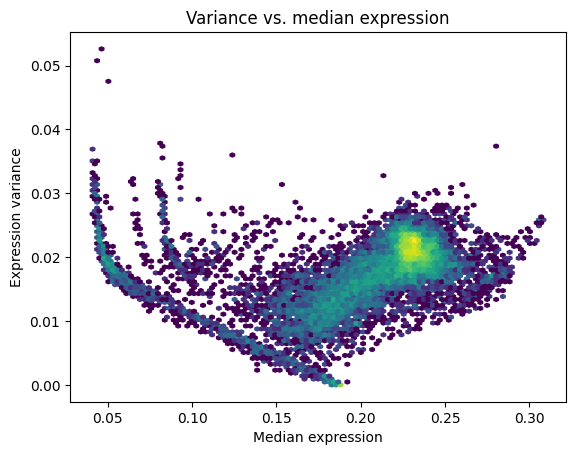

In [ ]:
# Prelimiary plot of variance by median expression
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

<Axes: xlabel='std', ylabel='Count'>

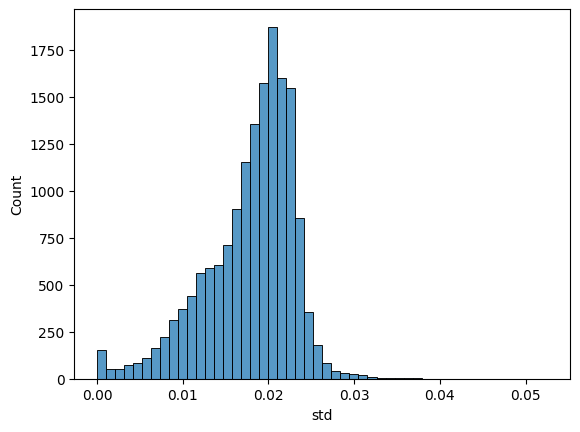

In [ ]:
# Plot variance distribution
sns.histplot(exp_stats['std'] ** 2, bins = 50)

In [ ]:
# Get 25th percentile cutoff
var_cutoff = np.percentile(exp_stats['std'] ** 2, 25)

# Pull bottom 25% variance samples
low_var_exps = exp_stats[exp_stats['std'] ** 2 < var_cutoff]

low_var_exps.shape

(4031, 8)

<Axes: xlabel='50%', ylabel='Count'>

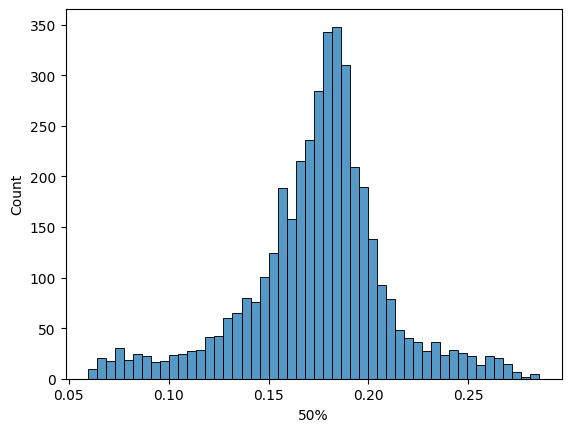

In [ ]:
# Get statistics on low variance experiments
low_var_exps = filtered_genes[low_var_exps.index].describe().T
sns.histplot(low_var_exps['50%'], bins = 50)

In [ ]:
# Get 40th percentile cutoff
med_cutoff = np.percentile(low_var_exps['50%'], 40)

# Pull bottom 40% median samples
exps_to_rm = low_var_exps[low_var_exps['50%'] < med_cutoff]

exps_to_rm.shape

(1612, 8)

Text(0.5, 1.0, 'Variance vs. median expression')

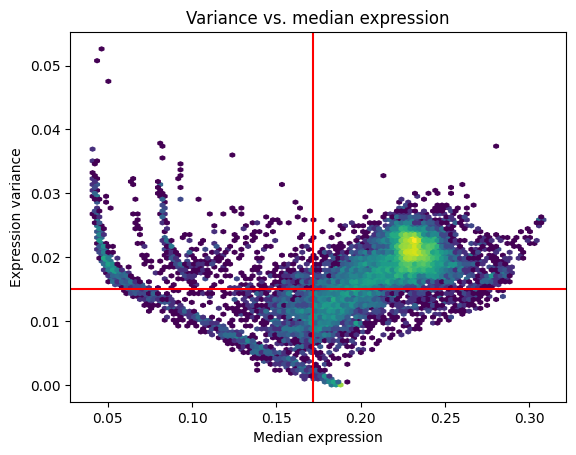

In [ ]:
# Make a plot with boundaries for filtering out samples - lower left quadrant
# will be dropped
plt.hexbin(
  x = exp_stats['50%'],
  y = exp_stats['std'] ** 2,
  bins = 'log'
)
plt.axvline(exps_to_rm['50%'].max(), color = 'red')
plt.axhline((exps_to_rm['std']**2).max(), color = 'red')

plt.xlabel("Median expression")
plt.ylabel("Expression variance")
plt.title("Variance vs. median expression")

In [ ]:
# Obtain final filtered dataset
filtered_df = filtered_genes.drop(exps_to_rm.index, axis = 1)
filtered_df.shape

(5751, 14510)

### Re-normalization

We pull the raw counts for these filtered data and then normalize again through:
- Ratio of Medians
- Log-transformed
- 0-1 scaled

#### Remove Unnecessary Columns

In [259]:
# These bad samples were in the original df - let's see if we still have them
bad_cols = [
  'df2...c.3.ncol.df2....1', 'df2...c.3.ncol.df2....10', 'df2...c.3.ncol.df2....11', 'df2...c.3.ncol.df2....12',
  'df2...c.3.ncol.df2....13', 'df2...c.3.ncol.df2....14', 'df2...c.3.ncol.df2....15', 'df2...c.3.ncol.df2....16',
  'df2...c.3.ncol.df2....17', 'df2...c.3.ncol.df2....18', 'df2...c.3.ncol.df2....19', 'df2...c.3.ncol.df2....2',
  'df2...c.3.ncol.df2....20', 'df2...c.3.ncol.df2....21', 'df2...c.3.ncol.df2....22', 'df2...c.3.ncol.df2....23',
  'df2...c.3.ncol.df2....26', 'df2...c.3.ncol.df2....27', 'df2...c.3.ncol.df2....28', 'df2...c.3.ncol.df2....3',
  'df2...c.3.ncol.df2....31', 'df2...c.3.ncol.df2....32', 'df2...c.3.ncol.df2....36', 'df2...c.3.ncol.df2....37',
  'df2...c.3.ncol.df2....38', 'df2...c.3.ncol.df2....39', 'df2...c.3.ncol.df2....4', 'df2...c.3.ncol.df2....40',
  'df2...c.3.ncol.df2....41', 'df2...c.3.ncol.df2....42', 'df2...c.3.ncol.df2....44', 'df2...c.3.ncol.df2....45',
  'df2...c.3.ncol.df2....48', 'df2...c.3.ncol.df2....50', 'df2...c.3.ncol.df2....51', 'df2...c.3.ncol.df2....52',
  'df2...c.3.ncol.df2....54', 'df2...c.3.ncol.df2....56', 'df2...c.3.ncol.df2....58', 'df2...c.3.ncol.df2....6',
  'df2...c.3.ncol.df2....63', 'df2...c.3.ncol.df2....65', 'df2...c.3.ncol.df2....7', 'df2...c.3.ncol.df2....71',
  'df2...c.3.ncol.df2....74', 'df2...c.3.ncol.df2....75', 'df2...c.3.ncol.df2....76', 'df2...c.3.ncol.df2....78',
  'df2...c.3.ncol.df2....8', 'df2...c.3.ncol.df2....83', 'df2...c.3.ncol.df2....9'
]

In [260]:
filtered_df.shape

(3608, 10154)

In [261]:
# We've filtered out the unnecessary columns already (good!)
filtered_df.columns[filtered_df.columns.str.startswith('ERX') | filtered_df.columns.str.startswith('SRX')].shape

(10154,)

#### Normalization

In [262]:
raw_df = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/Copy of num_reads_ecoli_pan_genome_part2_comp_ref_k15v3.csv',
  index_col = 0
)
raw_df.shape

(59521, 20241)

In [263]:
raw_df.index = raw_df['X']
raw_filt = raw_df.loc[filtered_df.index, filtered_df.columns]
raw_filt.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,89.000,210.000,184.000,97.000,138.000,147.000,372.990,115.000,29.022,57.192,...,1293.000,2456.0,1020.0,2966.00,2871.0,832.0,1343.000,1036.00,948.000,1176.000
11997cc26382b2c286cd502685a104a5_45,190.000,247.000,353.000,111.000,263.000,108.000,326.000,104.000,17.979,23.869,...,1592.000,2505.0,1812.0,506.25,647.0,501.0,761.877,563.00,611.659,599.889
11997cc26382b2c286cd502685a104a5_110,512.188,774.683,494.736,375.694,411.855,148.855,1310.018,278.331,26.225,25.298,...,4473.000,5772.0,3436.0,2976.00,4803.0,2792.0,2721.000,2274.00,2376.000,2393.000
11997cc26382b2c286cd502685a104a5_72,364.959,1070.884,348.464,655.238,418.039,217.520,1457.939,169.932,234.191,251.888,...,73509.995,105679.0,54749.0,1928.00,1996.0,8069.0,10965.000,8550.86,8671.000,105943.000
11997cc26382b2c286cd502685a104a5_273,100.000,168.000,70.185,0.000,0.000,28.000,106.000,72.000,10.000,7.000,...,190.000,262.0,157.0,183.00,253.0,120.0,116.000,100.00,73.000,83.000


In [264]:
# Ratio of Medians Scaling
norm_counts, size_factors = deseq2_norm(raw_filt.T)
norm_counts = norm_counts.T
norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,168.735077,224.454335,200.758238,168.972182,140.082481,232.088992,199.530930,279.017095,496.329284,784.934406,...,304.785171,420.689268,281.065900,1100.960673,848.571388,299.517514,363.337324,349.470625,332.820794,435.755021
11997cc26382b2c286cd502685a104a5_45,360.220952,264.001051,385.150315,193.359919,266.968787,170.514361,174.393638,252.328503,307.473785,327.591260,...,375.265269,429.082498,499.305305,187.916838,191.231518,180.358503,206.119397,189.915021,214.739276,222.282861
11997cc26382b2c286cd502685a104a5_110,971.057099,828.004559,539.795259,654.451905,418.070075,235.017734,700.793881,675.296584,448.495468,347.203641,...,1054.372831,988.688295,946.806307,1104.672611,1419.605844,1005.111656,736.143604,767.081274,834.158445,886.702182
11997cc26382b2c286cd502685a104a5_72,691.925675,1144.593123,380.201188,1141.412313,424.347395,343.428554,779.924192,412.295070,4005.094458,3457.049198,...,17327.731176,18101.800135,15086.349971,715.661557,589.950711,2904.815887,2966.488281,2884.434734,3044.186818,39256.117551
11997cc26382b2c286cd502685a104a5_273,189.589975,179.563468,76.577266,0.000000,0.000000,44.207427,56.704680,174.688964,171.018291,96.071843,...,44.786684,44.878090,43.262104,67.928457,74.778322,43.199641,31.382822,33.732686,25.628605,30.754819


In [265]:
# Log2 scaling
log_norm_counts = np.log2(norm_counts + 1)
log_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,7.407141,7.816691,7.656484,7.409155,7.140395,7.864737,7.647681,8.129371,8.958058,9.618265,...,8.256375,8.720036,8.139888,10.105857,9.730591,8.231305,8.509131,8.453150,8.382930,8.770680
11997cc26382b2c286cd502685a104a5_45,8.496738,8.049854,8.593019,7.602587,8.065921,7.422186,7.454453,7.984866,8.269004,8.360150,...,8.555606,8.748470,8.966665,7.561607,7.586701,7.502701,7.694319,7.576787,7.753145,7.802729
11997cc26382b2c286cd502685a104a5_110,9.924897,9.695236,9.078939,9.356346,8.711048,7.882751,9.454904,9.401512,8.812163,8.443787,...,10.043537,9.950830,9.888448,10.110709,10.472291,9.974575,9.525802,9.585115,9.705906,9.793932
11997cc26382b2c286cd502685a104a5_72,9.436557,10.161879,8.574409,10.157868,8.732498,8.428061,9.609039,8.691028,11.967981,11.755743,...,14.080878,14.143925,13.881052,9.485148,9.206894,11.504728,11.535027,11.494573,11.572315,15.260667
11997cc26382b2c286cd502685a104a5_273,7.574328,7.496362,6.277562,0.000000,0.000000,5.498488,5.850616,7.456880,7.426418,6.600981,...,5.516856,5.519733,5.468000,6.107028,6.243713,5.465963,5.017157,5.118222,4.734905,4.988904


In [266]:
# 0-1 scaling
log_01_norm_counts = (log_norm_counts - log_norm_counts.min()) / (log_norm_counts.max() - log_norm_counts.min())
log_01_norm_counts.head()

,ERX358242.salmon,ERX358243.salmon,ERX358244.salmon,ERX358245.salmon,ERX358246.salmon,ERX358247.salmon,ERX358248.salmon,ERX358249.salmon,ERX644787.salmon,ERX644790.salmon,...,SRX28568279.salmon,SRX28568280.salmon,SRX28568281.salmon,SRX28568282.salmon,SRX28568283.salmon,SRX28568284.salmon,SRX28568285.salmon,SRX28568286.salmon,SRX28568287.salmon,SRX28568288.salmon
11997cc26382b2c286cd502685a104a5_13,0.462185,0.494386,0.487966,0.452542,0.445669,0.461694,0.473013,0.487469,0.519818,0.539276,...,0.498947,0.528333,0.489850,0.599973,0.579576,0.500972,0.517158,0.515956,0.511575,0.523563
11997cc26382b2c286cd502685a104a5_45,0.530173,0.509133,0.547654,0.464356,0.503436,0.435714,0.461062,0.478804,0.479833,0.468736,...,0.517031,0.530055,0.539605,0.448924,0.451881,0.456627,0.467637,0.462465,0.473142,0.465782
11997cc26382b2c286cd502685a104a5_110,0.619286,0.613199,0.578622,0.571474,0.543702,0.462752,0.584791,0.563752,0.511352,0.473425,...,0.606949,0.602904,0.595077,0.600261,0.623754,0.607070,0.578949,0.585047,0.592310,0.584646
11997cc26382b2c286cd502685a104a5_72,0.588815,0.642713,0.546467,0.620430,0.545041,0.494764,0.594324,0.521149,0.694477,0.659120,...,0.850933,0.856957,0.835347,0.563122,0.548384,0.700198,0.701063,0.701595,0.706209,0.910981
11997cc26382b2c286cd502685a104a5_273,0.472617,0.474126,0.400084,0.000000,0.000000,0.322785,0.361864,0.447144,0.430940,0.370103,...,0.333393,0.334432,0.329059,0.362567,0.371890,0.332668,0.304927,0.312401,0.288951,0.297811


In [267]:
# Save to a CSV file
log_01_norm_counts.to_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index = True
)

In [268]:
# Verify that I can load the CSV back in here
final_filt = pd.read_csv(
  '/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_lcn01_medmean_normal_muk.csv',
  index_col = 0
)
final_filt.shape

(3608, 10154)

### Dimensionality Reduction

#### PCA

In [ ]:
from sklearn.decomposition import PCA

##### Reduce samples

In [ ]:
X_pca = PCA(n_components=50).fit_transform(filtered_df)
df_pca = pd.DataFrame(X_pca)
df_pca.index = filtered_df.index
df_pca.columns = [f"PC{i}" for i in range(1, 51)]

In [ ]:
df_pca.shape

(5751, 50)

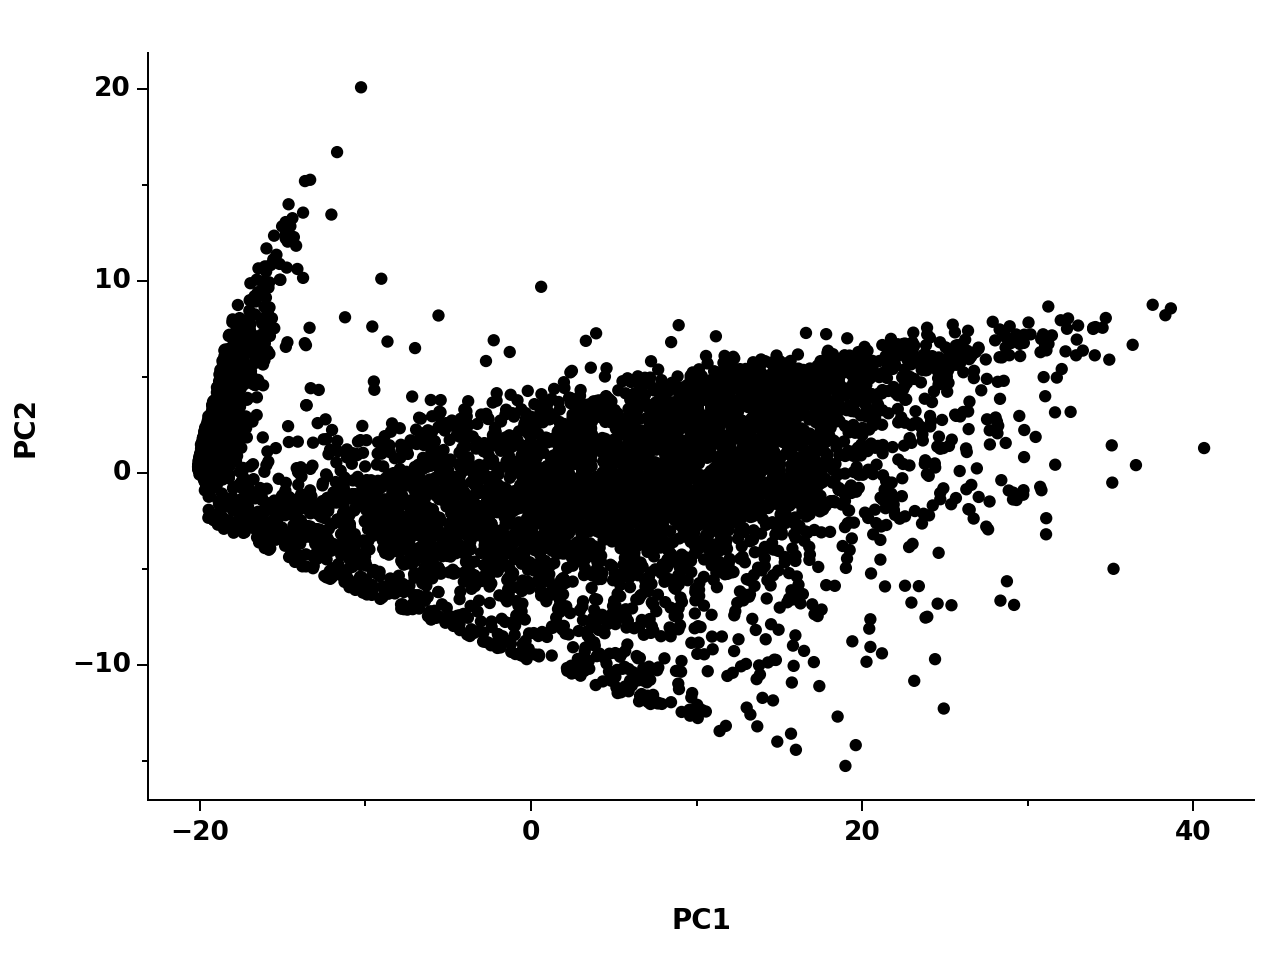

<Figure Size: (640 x 480)>

In [ ]:
p1 = (
  ggplot(df_pca, aes(x="PC1", y="PC2"))
  + geom_point()
  + theme_prism()
)
p1

##### Reduce genes

In [ ]:
Y_pca = PCA(n_components=50).fit_transform(filtered_df.T)
df_pca2 = pd.DataFrame(Y_pca)
df_pca2.index = filtered_df.columns
df_pca2.columns = [f"PC{i}" for i in range(1, 51)]

In [ ]:
df_pca2.shape

(14510, 50)

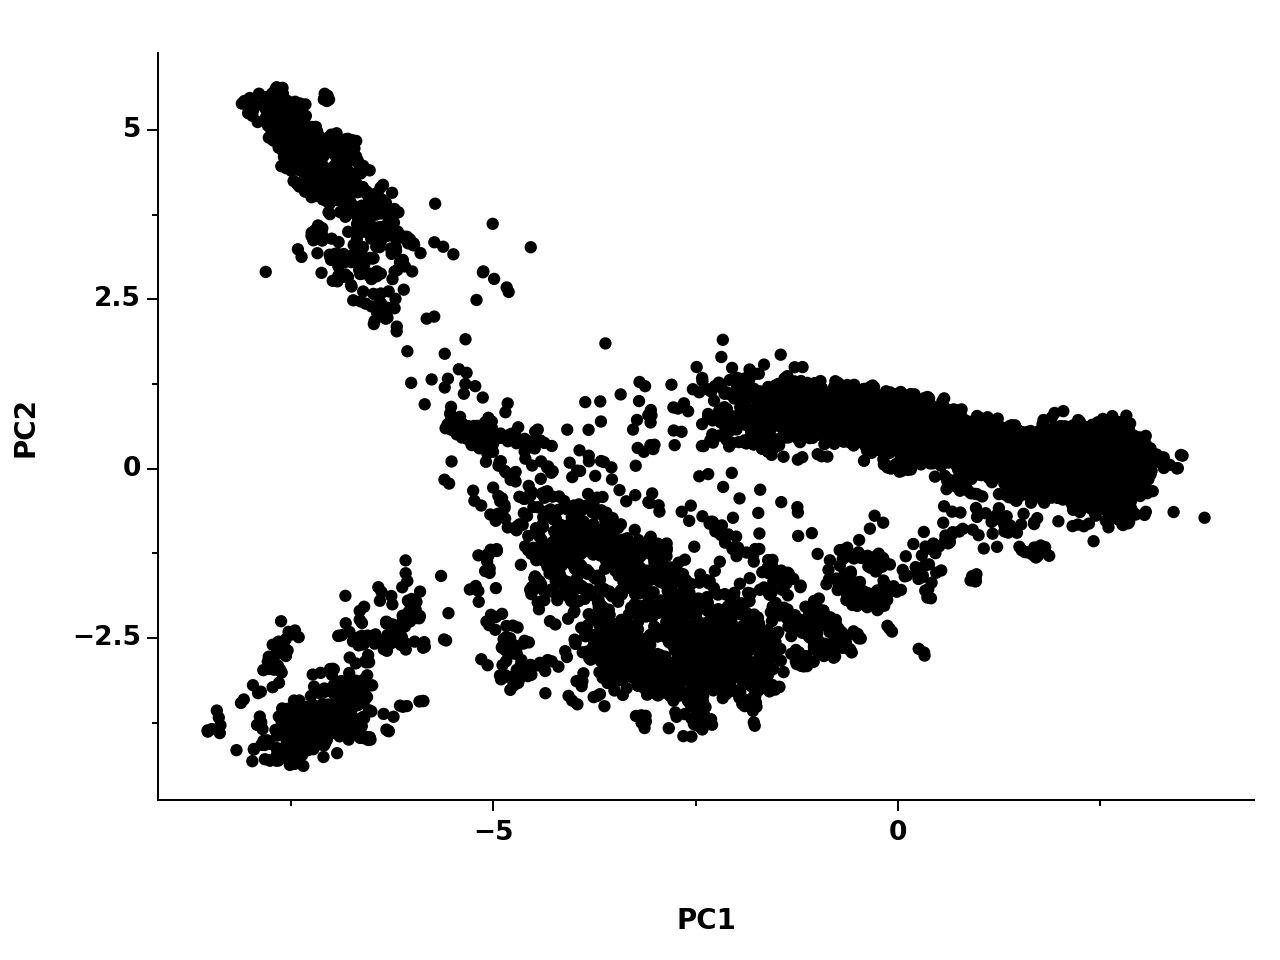

<Figure Size: (640 x 480)>

In [ ]:
p2 = (
  ggplot(df_pca2, aes(x="PC1", y="PC2"))
  + geom_point()
  + theme_prism()
)
p2

#### t-SNE

In [ ]:
from sklearn.manifold import TSNE

##### Reduce samples

In [ ]:
X_tsne = TSNE(learning_rate=100).fit_transform(filtered_df)
df_tsne = pd.DataFrame(X_tsne)

In [ ]:
df_tsne.columns = ["tSNE1", "tSNE2"]
df_tsne.index = filtered_df.index

In [ ]:
df_tsne.shape

(5751, 2)

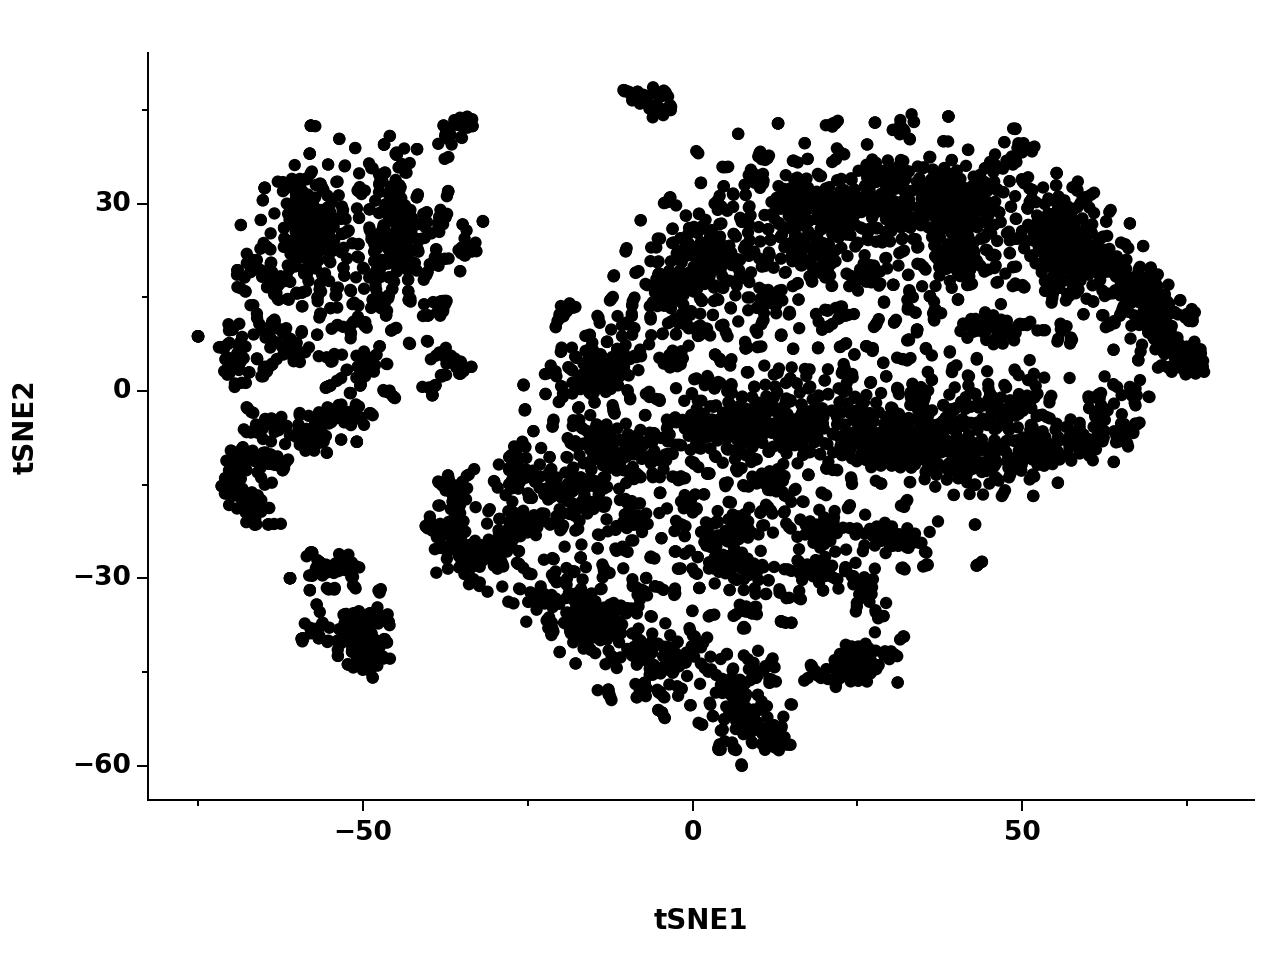

<Figure Size: (640 x 480)>

In [ ]:
p3 = (
  ggplot(df_tsne, aes(x='tSNE1', y='tSNE2'))
  + geom_point()
  + theme_prism()
)
p3

##### Reduce genes

In [ ]:
Y_tsne = TSNE(learning_rate=100).fit_transform(filtered_df.T)
df_tsne2 = pd.DataFrame(Y_tsne)

In [ ]:
df_tsne2.columns = ["tSNE1", "tSNE2"]
df_tsne2.index = filtered_df.columns

In [ ]:
df_tsne2.shape

(14510, 2)

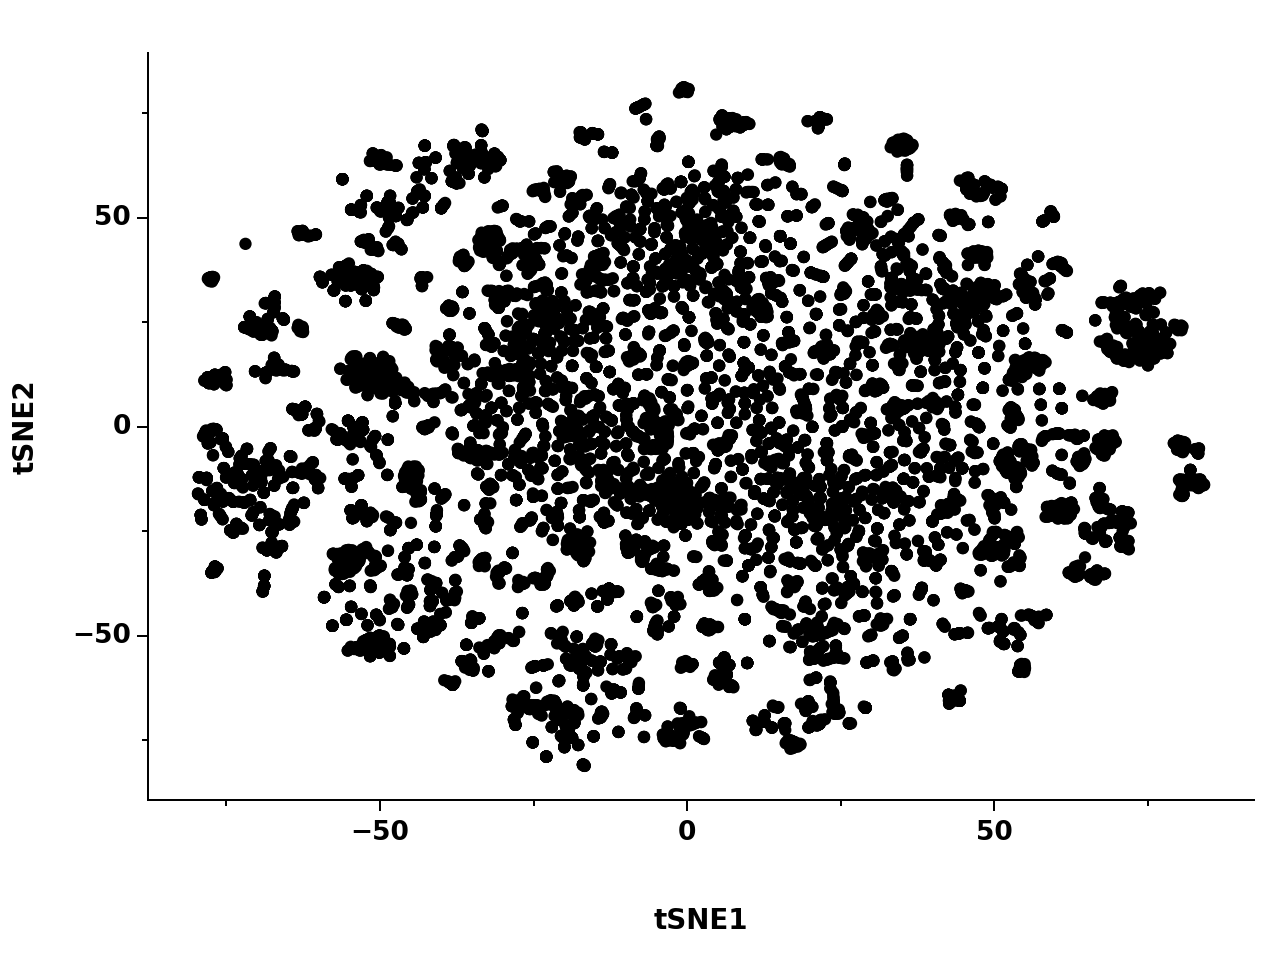

<Figure Size: (640 x 480)>

In [ ]:
p4 = (
  ggplot(df_tsne2, aes(x='tSNE1', y='tSNE2'))
  + geom_point()
  + theme_prism()
)
p4

#### UMAP

In [ ]:
from umap import UMAP

###### Reduce samples

In [ ]:
X_umap = UMAP().fit_transform(filtered_df)

In [ ]:
df_umap = pd.DataFrame(X_umap)
df_umap.columns = ['UMAP1', 'UMAP2']
df_umap.index = filtered_df.index

In [ ]:
df_umap.shape

(5751, 2)

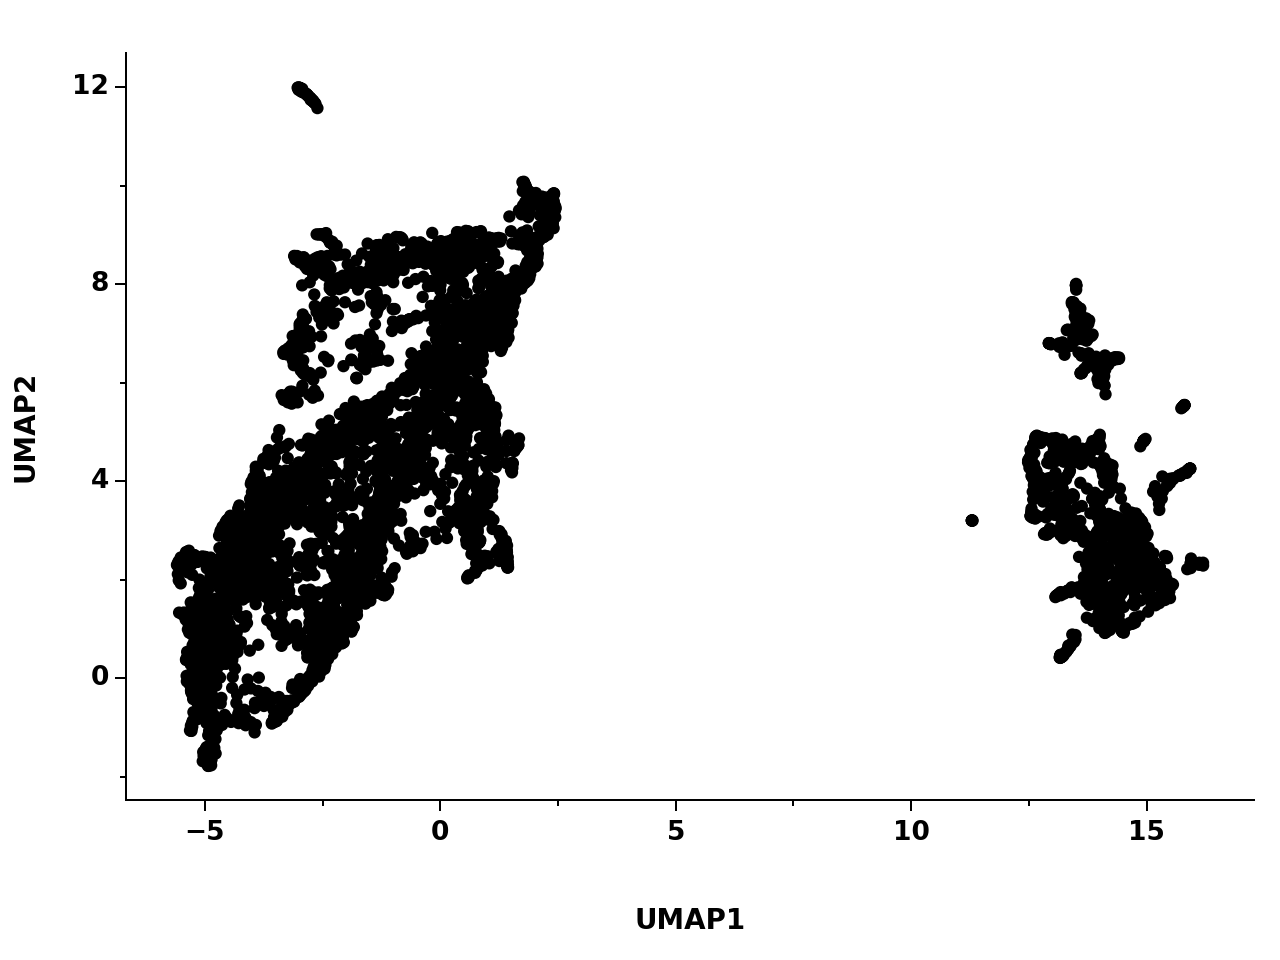

<Figure Size: (640 x 480)>

In [ ]:
p5 = (
  ggplot(df_umap, aes(x='UMAP1', y='UMAP2'))
  + geom_point()
  + theme_prism()
)
p5

###### Reduce genes

In [ ]:
Y_umap = UMAP().fit_transform(filtered_df.T)

In [ ]:
df_umap2 = pd.DataFrame(Y_umap)
df_umap2.columns = ['UMAP1', 'UMAP2']
df_umap2.index = filtered_df.columns

In [ ]:
df_umap2.shape

(14510, 2)

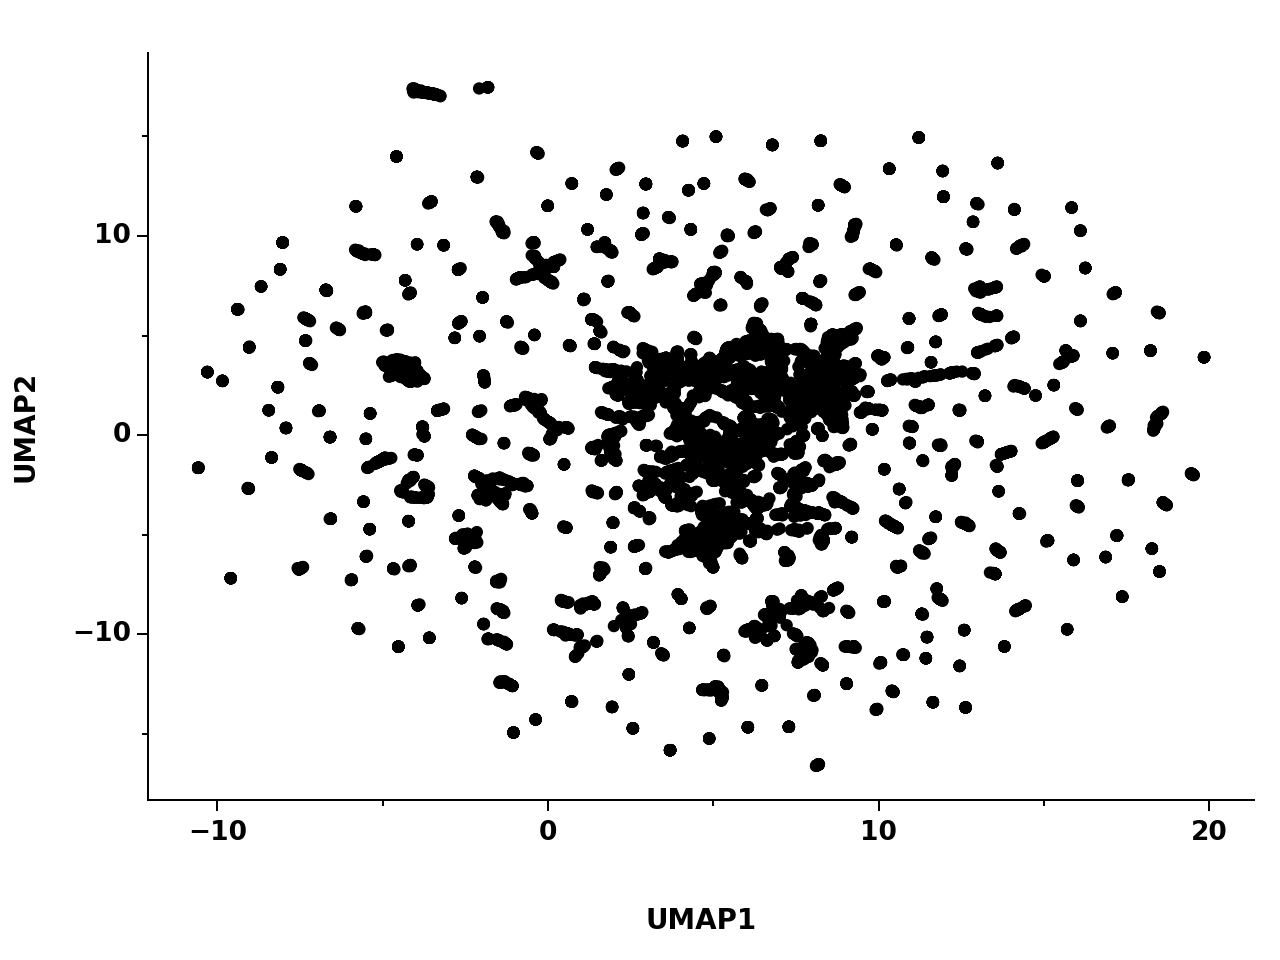

<Figure Size: (640 x 480)>

In [ ]:
p6 = (
  ggplot(df_umap2, aes(x='UMAP1', y='UMAP2'))
  + geom_point()
  + theme_prism()
)
p6

#### ICA

In [ ]:
from sklearn.decomposition import FastICA

###### Reduce samples

In [ ]:
X_ica = FastICA(n_components=50).fit_transform(filtered_df)

In [ ]:
df_ica = pd.DataFrame(X_ica)
df_ica.columns = [f"IC{i}" for i in range(1, 51)]
df_ica.index = filtered_df.index

In [ ]:
df_ica.shape

(5751, 50)

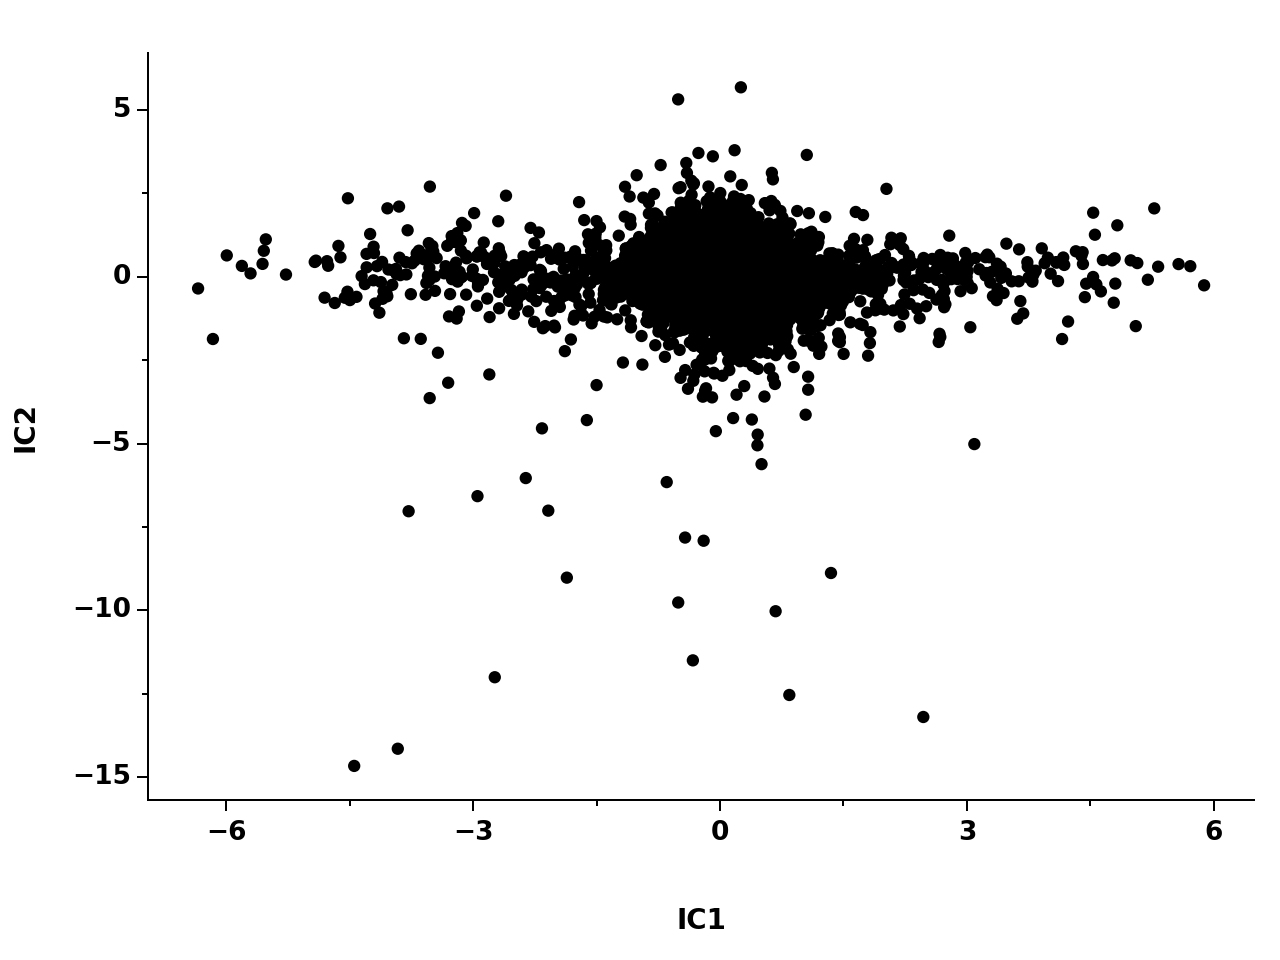

<Figure Size: (640 x 480)>

In [ ]:
p7 = (
  ggplot(df_ica, aes(x="IC1", y="IC2"))
  + geom_point()
  + theme_prism()
)
p7

###### Reduce genes

In [ ]:
Y_ica = FastICA(n_components=50).fit_transform(filtered_df.T)

In [ ]:
df_ica2 = pd.DataFrame(Y_ica)
df_ica2.columns = [f"IC{i}" for i in range(1, 51)]
df_ica2.index = filtered_df.columns

In [ ]:
df_ica2.shape

(14510, 50)

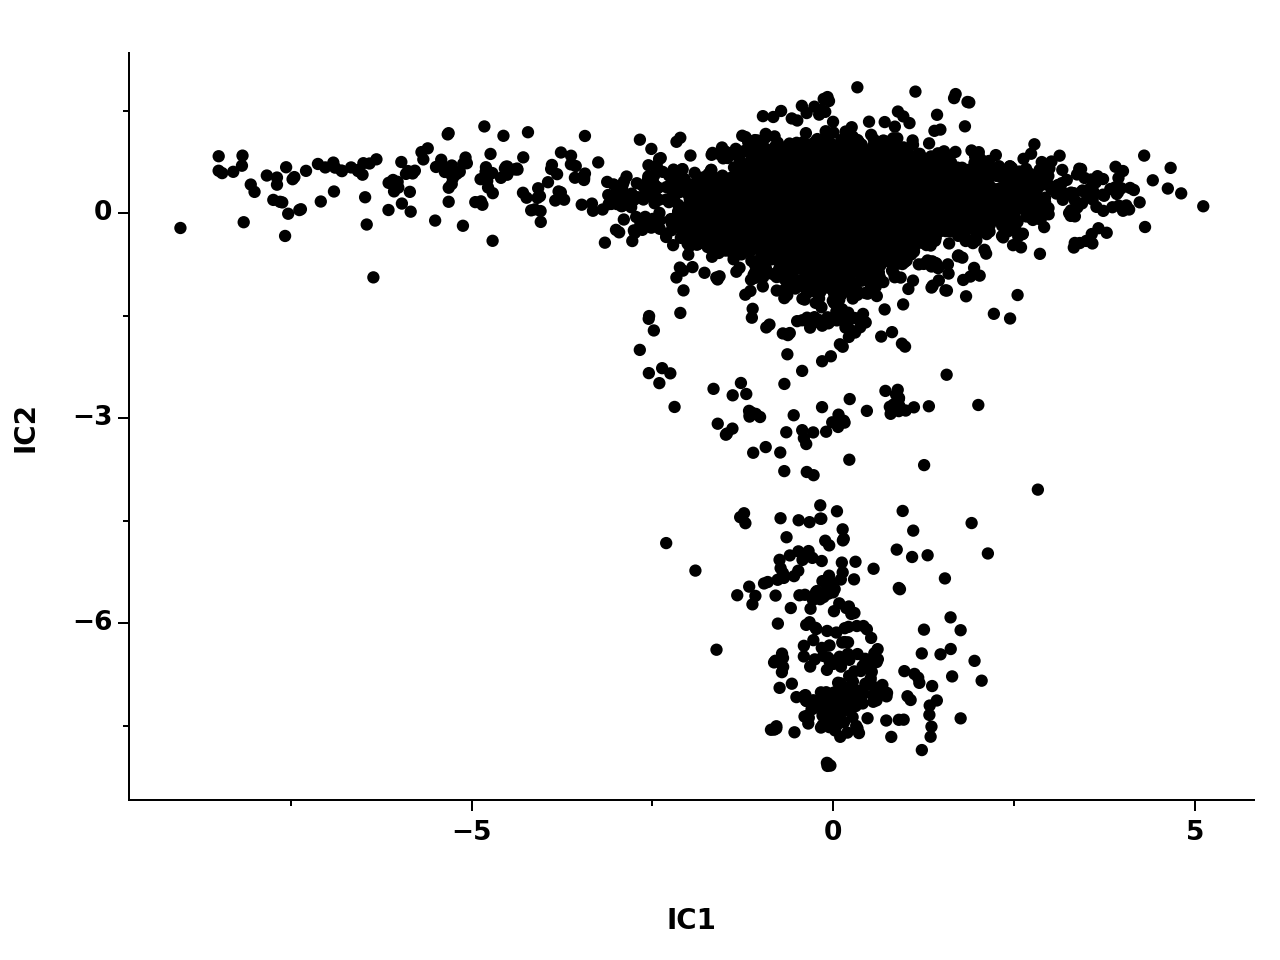

<Figure Size: (640 x 480)>

In [ ]:
p8 = (
  ggplot(df_ica2, aes(x="IC1", y="IC2"))
  + geom_point()
  + theme_prism()
)
p8

## 3. Genomic Mapping

Here we are trying to map E. coli genes to S. aureus genes using BLAST, k-mer mapping, and AlphaFold.

### BLAST

In [ ]:
!pip install -qq biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 24.1 MB/s eta 0:00:00


In [ ]:
from Bio import Blast

In [ ]:
Blast.email = "thanigam@union.edu"

stream = Blast.qblast(
    "blastn",
    "nt",
    "ATGCGTACGTAGCTAGCTAGCTAG"
)

records = Blast.parse(stream)

for record in records:
    print(record)

  Query: Query_4190519 (length=24)
         No definition line
   Hits: ----  -----  ----------------------------------------------------------
            #  # HSP  ID + description
         ----  -----  ----------------------------------------------------------
            0      1  gi|554773949|dbj|AK427682.1|  Brachypodium distachyon m...
            1      1  gi|1371094312|ref|XM_003580247.4|  PREDICTED: Brachypod...
            2      1  gi|554778458|dbj|AK432223.1|  Brachypodium distachyon m...
            3      1  gi|554775781|dbj|AK429527.1|  Brachypodium distachyon m...
            4      1  gi|2123696933|ref|XM_044479345.1|  PREDICTED: Triticum ...
            5      1  gi|2915359631|ref|XM_071333331.1|  PREDICTED: Salvelinu...
            6      1  gi|2501050558|ref|XM_055870434.1|  PREDICTED: Salvelinu...
            7      1  gi|242381309|emb|FP096780.1|  Phyllostachys edulis cDNA...
            8      1  gi|1882627362|ref|XM_018953277.2|  PREDICTED: Juglans r...
       

## 4. Train models

In a previous hyperparameter seach I landed on the following:

* enccoding dimension: 459
* L1 normalizaion: 0
* L2 normalization: 0
* activation functios: tanh
* tied: True
* epochs: 50
* initialization: glorot_uniform
* batch_size: 15
* dropout: 0
* momentum: 0.6
* learning rate: 0.5

In [ ]:
# a dict to store the models
comps = ["ecmg_mgs_lcn01.csv","ecmgp_lcn01.csv"]
model_dict_post = {}

# for timing how long training takes
stime = time.time()
ltime = 0
c = 0

# random seed, maybe shouldn't be sequential
seeds = list(range(0,3))

# loop through compendia and random seeds
for comp in comps:
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        print(name)
        ttime = time.time()
        sa = SeqAdage.SeqAdage('/content/drive/My Drive/Comp-Bio-Projs-S26/data/muk-in-use/ecmg_mgs_lcn01.csv',
                                                  seed=seed+100,
                                                  enc_dim = 450,
                                                  kl1=0,
                                                  kl2=0,
                                                  act = "tanh",
                                                  act2="tanh",
                                                  tied = True,
                                                  epochs=100,
                                                  init="glorot_uniform",
                                                  batch_size=15,
                                                  dropout = 0,
                                                  mm = 0.6,
                                                  lr = 0.5)
        mseq = sa.train_model()
        temp = ad.Adage(sa.autoencoder, sa.history, sa.all_comp)
        model_dict_post[name] = temp
        ltime = ((time.time() - ttime) + ltime)
        c+=1

rtime = time.time() - stime

ad_ecmg_mgs_lcn01.csv_2025_09_01_100
Epoch 1/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0183 - val_loss: 0.0134
Epoch 2/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0129 - val_loss: 0.0126
Epoch 3/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0124 - val_loss: 0.0122
Epoch 4/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0120 - val_loss: 0.0120
Epoch 5/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0118 - val_loss: 0.0119
Epoch 6/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0117 - val_loss: 0.0118
Epoch 7/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0116 - val_loss: 0.0117
Epoch 8/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0115 - val_loss: 0.0116
Epoch 9/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0114 - val_loss: 0.0115
Epoch 10/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0113 - val_loss: 0.0115
Epoch 11/100
969/969 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0113 - val_loss: 0.0114
Epoc

In [ ]:
print(rtime)
print(c)
print(ltime / c)
print(rtime / 60)

2222.3970215320587
6
370.3973372777303
37.03995035886764


## 5. Plot training loss

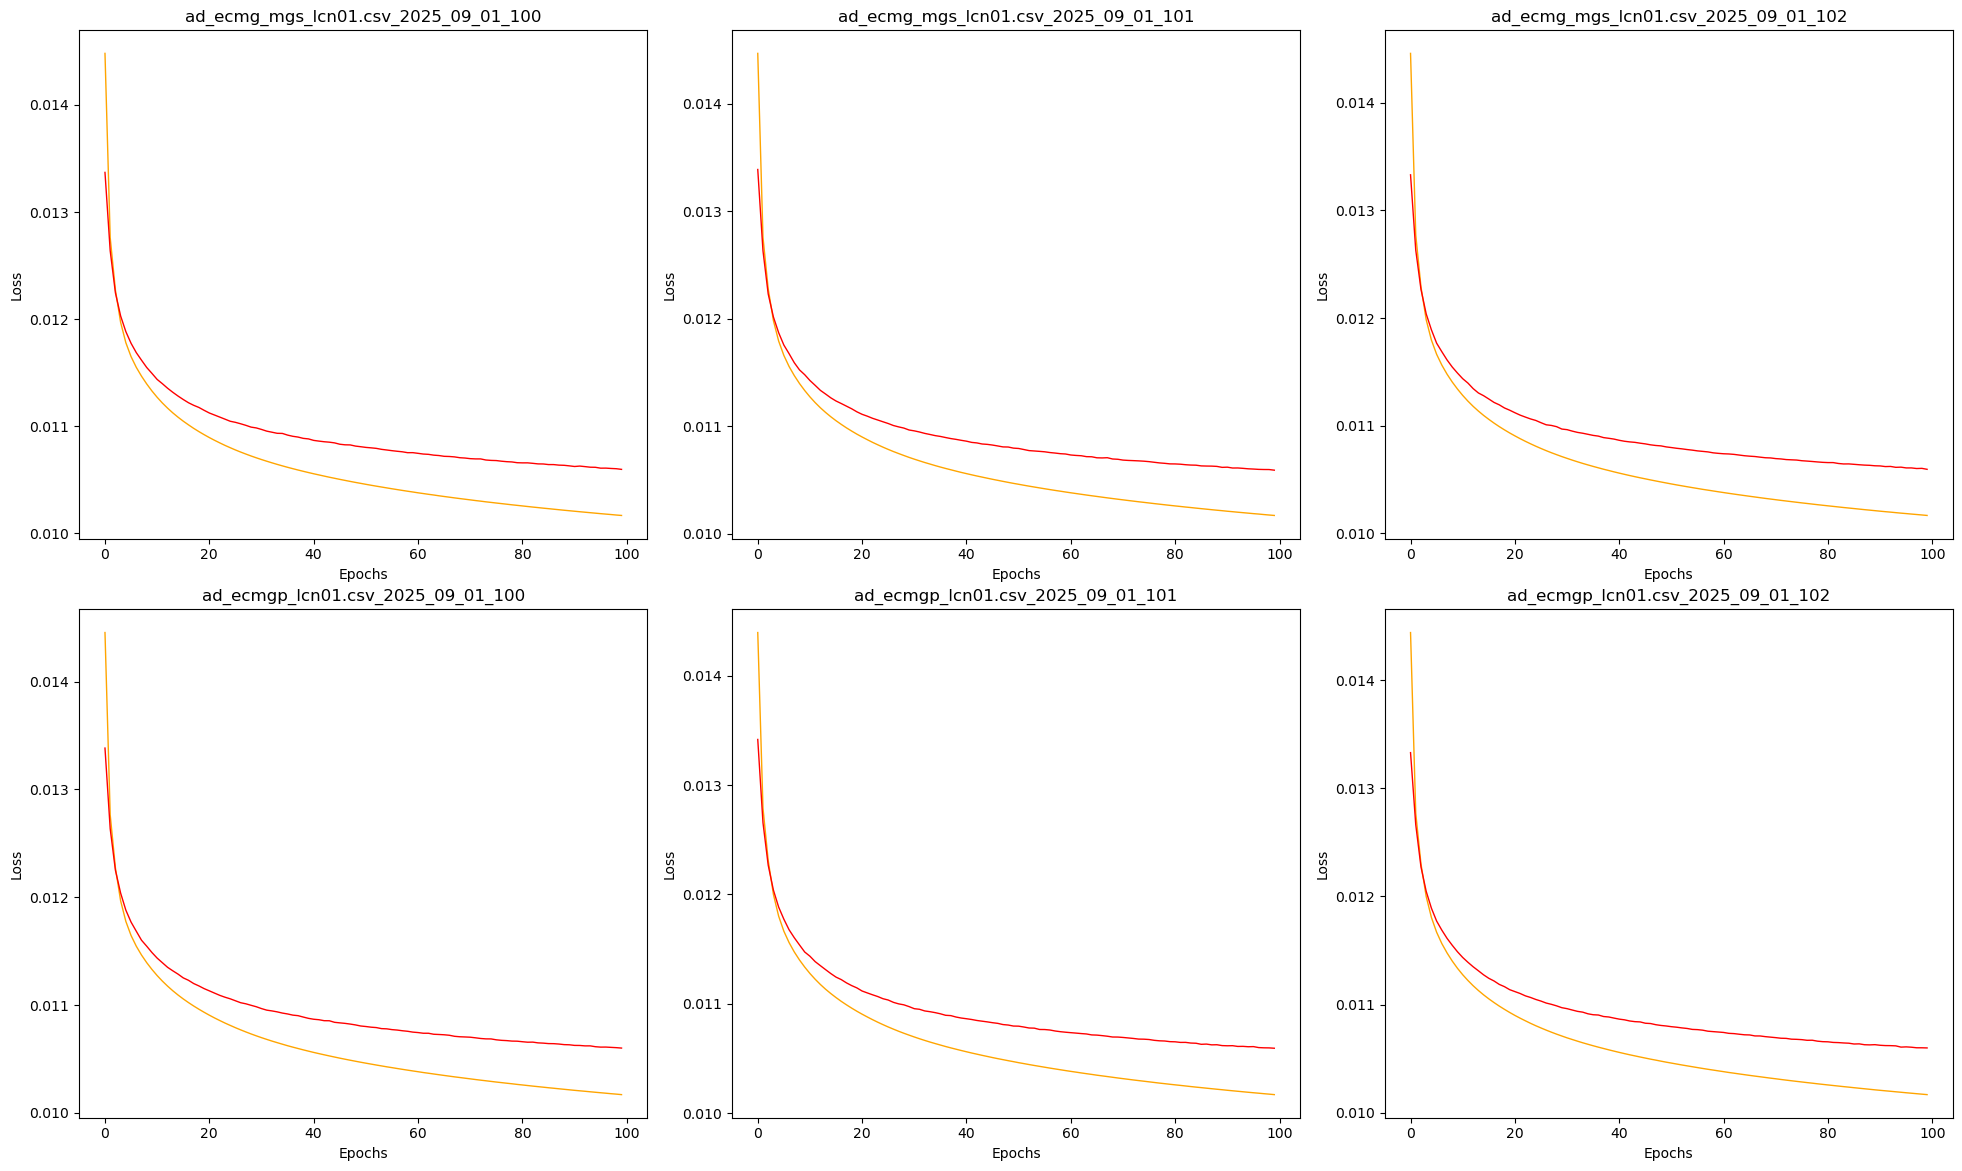

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps)
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(xd*10 ,yd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for comp in comps:
    xi=0
    for seed in seeds:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        # training loss in orange
        ax[yi,xi].plot(list(range(0,100)), model_temp.loss, linewidth=1,
                       markersize=2, color = 'orange')
        # cross validation loss in red
        ax[yi,xi].plot(list(range(0,100)), model_temp.val_loss,
                       linewidth=1, markersize=2, color = 'red')
        ax[yi,xi].set(title = name, xlabel = 'Epochs', ylabel = 'Loss')
        xi+=1
    yi+=1

## 6. Plot weight distributions

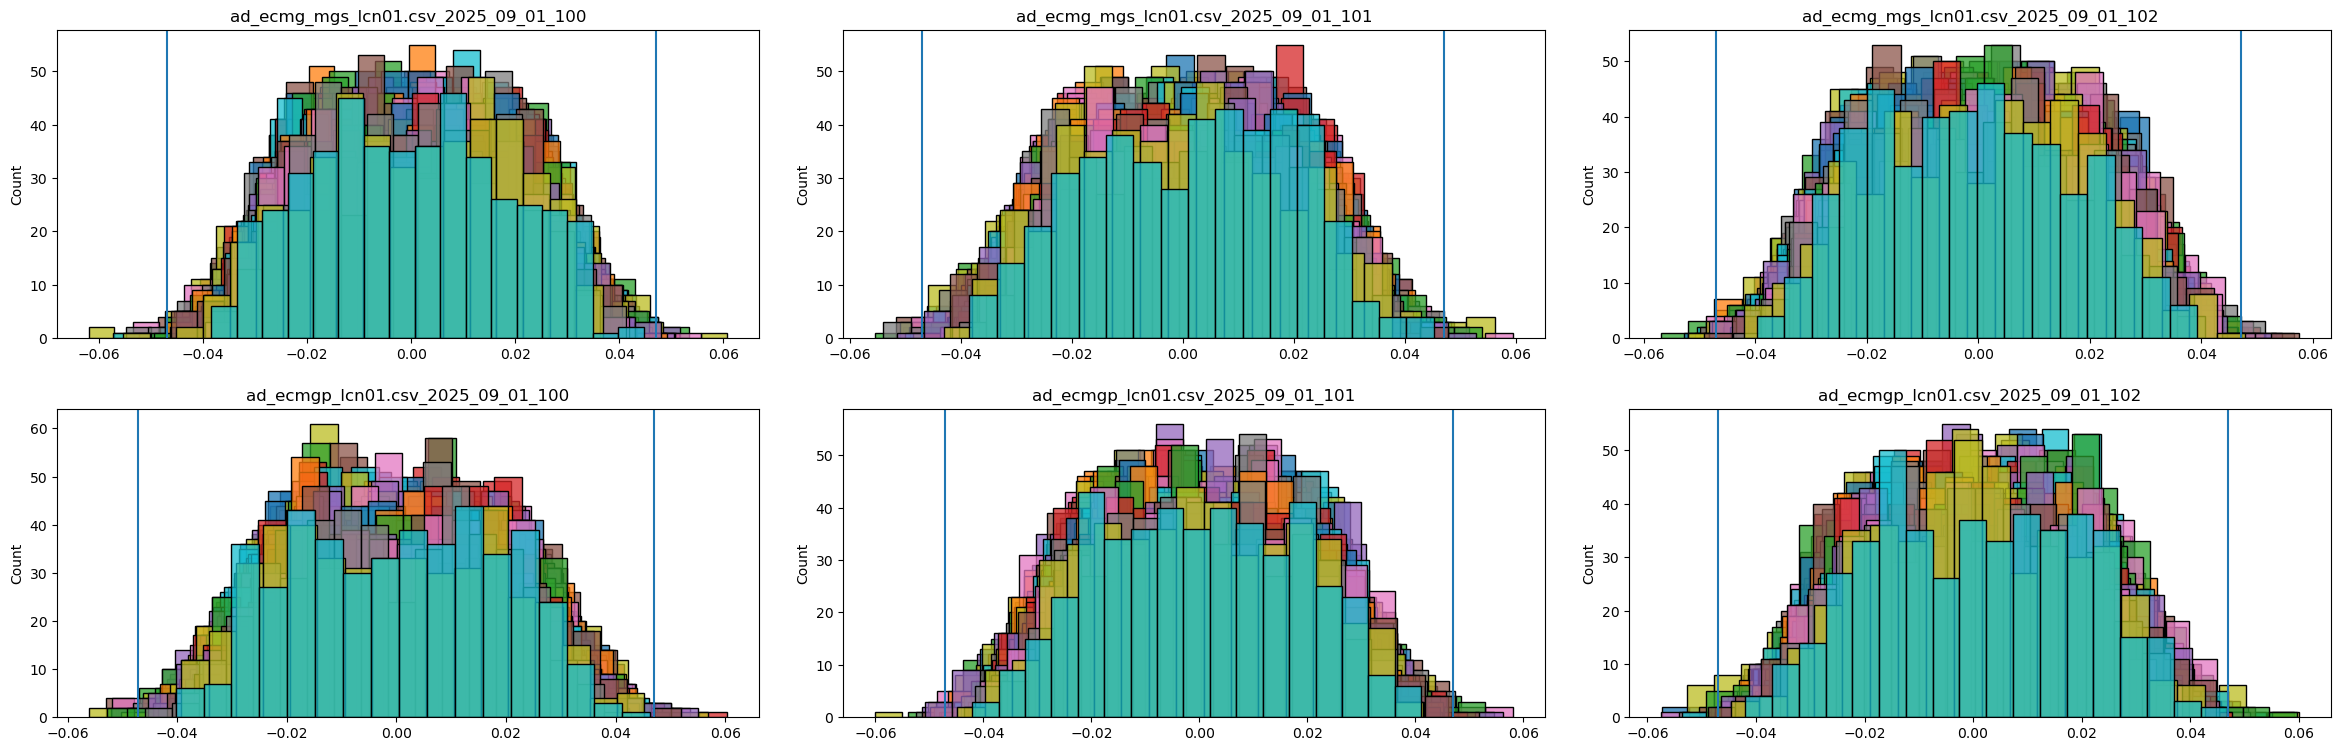

In [ ]:
# set layout for panels of compendia and seeds
xd = len(comps)
yd = len(seeds)
fig, ax = plt.subplots(xd, yd,figsize=(yd*8 ,xd *4))
fig.tight_layout(pad=3.0)

# plot each model in a facet
xi = 0
yi = 0
for seed in seeds:
    xi=0
    for comp in comps:
        name = 'ad_' + comp + '_2025_09_01_' + str(seed+100)
        model_temp = model_dict_post[name]
        for node in range(0,100):
            # in each hist, color each hidden node vector distribution
            sns.histplot(model_temp.weights[node],
                ax=ax[xi,yi],
                binwidth = 0.005,
                kde=False)
        # add markers for height/low weight cutoffs
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*2.5)
        ax[xi,yi].axvline(x = np.std(model_temp.weights)*-2.5)
        ax[xi,yi].set(title = name)
        xi+=1
    yi+=1